h0 (initial) : {'Price': '0', 'RAM': '0', 'Storage': '0', 'Brand': '0', 'Battery': '0'}

Example 1 (Yes): positive -> h1 = {'Price': 'Medium', 'RAM': '16GB', 'Storage': '512GB', 'Brand': 'Dell', 'Battery': 'Long'}
Example 2 (Yes): positive -> h2 = {'Price': 'Medium', 'RAM': '16GB', 'Storage': '512GB', 'Brand': '?', 'Battery': 'Long'}
Example 3 (No): negative -> ignored
Example 4 (Yes): positive -> h4 = {'Price': 'Medium', 'RAM': '16GB', 'Storage': '?', 'Brand': '?', 'Battery': 'Long'}

Final hypothesis: {'Price': 'Medium', 'RAM': '16GB', 'Storage': '?', 'Brand': '?', 'Battery': 'Long'}
Step-by-step hypothesis:
  h0: {'Price': '0', 'RAM': '0', 'Storage': '0', 'Brand': '0', 'Battery': '0'}
  h1: {'Price': 'Medium', 'RAM': '16GB', 'Storage': '512GB', 'Brand': 'Dell', 'Battery': 'Long'}
  h2: {'Price': 'Medium', 'RAM': '16GB', 'Storage': '512GB', 'Brand': '?', 'Battery': 'Long'}
  Ex3 (neg): {'Price': 'Medium', 'RAM': '16GB', 'Storage': '512GB', 'Brand': '?', 'Battery': 'Long'}
  h4: {'Pri

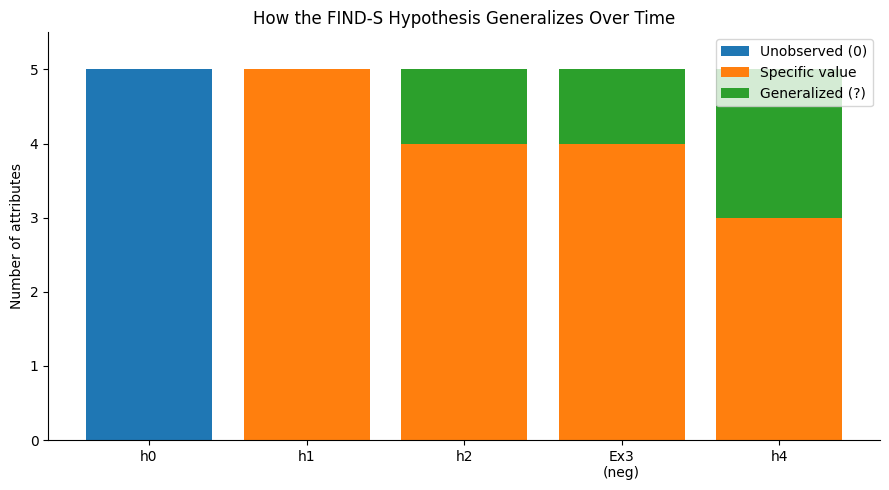

Saved: laptop_specificity_trend.png


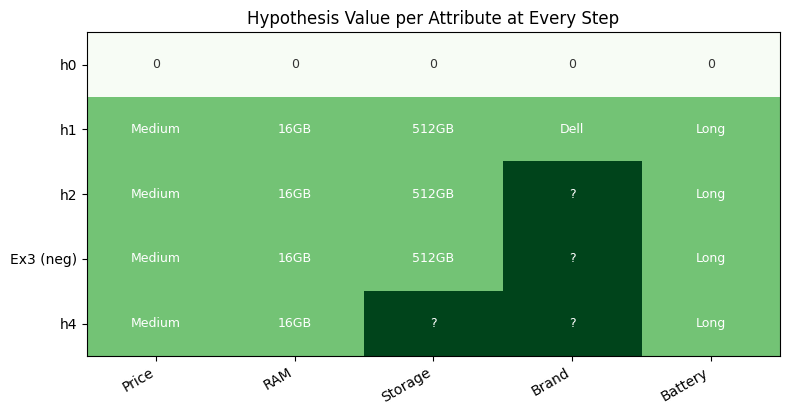

Saved: laptop_hypothesis_heatmap.png


In [1]:
"""
FIND-S Algorithm - New Dataset: Laptop Purchase
================================================
Learns the maximally specific hypothesis consistent with all positive
training examples. Negative examples are ignored.

Dataset:
    Price, RAM, Storage, Brand, Battery -> BuyLaptop

Hypothesis notation:
    '?' -> any value is acceptable
    '0' -> no value has been observed yet
    value -> a specific required value
"""

# ================================================================
# 1. FIND-S CORE ALGORITHM
# ================================================================

def find_s(training_data, target_col="BuyLaptop", positive_label="Yes"):

    # Get input attributes (everything except target)
    attributes = [
        a for a in training_data[0].keys()
        if a != target_col
    ]

    # Start with the most specific hypothesis
    hypothesis = {
        attr: "0"
        for attr in attributes
    }

    print(f"h0 (initial) : {hypothesis}\n")

    # Process each training example
    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # FIND-S ignores negative examples
        if label != positive_label:
            print(
                f"Example {i} ({label}): "
                f"negative -> ignored"
            )
            continue

        # Update hypothesis using positive example
        for attr in attributes:

            # First positive example:
            # directly copy its value
            if hypothesis[attr] == "0":
                hypothesis[attr] = example[attr]

            # If values differ:
            # generalize the attribute to '?'
            elif hypothesis[attr] != example[attr]:
                hypothesis[attr] = "?"

            # If values are the same:
            # keep the current value

        print(
            f"Example {i} ({label}): "
            f"positive -> h{i} = {hypothesis}"
        )

    print(f"\nFinal hypothesis: {hypothesis}")

    return hypothesis


# ================================================================
# 2. NEW LAPTOP PURCHASE DATASET
# ================================================================

if __name__ == "__main__":

    training_data = [

        # Positive examples
        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "512GB",
            "Brand": "Dell",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },

        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "512GB",
            "Brand": "HP",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },

        # Negative example - ignored by FIND-S
        {
            "Price": "High",
            "RAM": "8GB",
            "Storage": "256GB",
            "Brand": "HP",
            "Battery": "Short",
            "BuyLaptop": "No"
        },

        # Positive example
        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "1TB",
            "Brand": "Lenovo",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },
    ]

    final_hypothesis = find_s(training_data)


# ================================================================
# 3. FIND-S WITH HISTORY + VISUAL ANALYSIS
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


def find_s_with_history(
    training_data,
    target_col="BuyLaptop",
    positive_label="Yes"
):

    attributes = [
        a for a in training_data[0].keys()
        if a != target_col
    ]

    hypothesis = {
        attr: "0"
        for attr in attributes
    }

    # Save initial hypothesis
    history = [
        ("h0", dict(hypothesis), None)
    ]

    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # Negative -> ignore but save unchanged hypothesis
        if label != positive_label:

            history.append(
                (f"Ex{i}\n(neg)", dict(hypothesis), False)
            )

            continue

        for attr in attributes:

            if hypothesis[attr] == "0":
                hypothesis[attr] = example[attr]

            elif hypothesis[attr] != example[attr]:
                hypothesis[attr] = "?"

        # Save snapshot after positive example
        history.append(
            (f"h{i}", dict(hypothesis), True)
        )

    return hypothesis, history, attributes


# ================================================================
# 4. SPECIFICITY TREND GRAPH
# ================================================================

def plot_specificity_trend(
    history,
    attributes,
    save_as="laptop_specificity_trend.png"
):

    steps = [h[0] for h in history]

    unobserved = []
    specific = []
    general = []

    for _, hyp, _ in history:

        # Count '?' attributes
        g = sum(
            1 for v in hyp.values()
            if v == "?"
        )

        # Count '0' attributes
        u = sum(
            1 for v in hyp.values()
            if v == "0"
        )

        # Remaining attributes are specific
        s = len(attributes) - g - u

        unobserved.append(u)
        specific.append(s)
        general.append(g)

    x = np.arange(len(steps))

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(
        x,
        unobserved,
        label="Unobserved (0)"
    )

    ax.bar(
        x,
        specific,
        bottom=unobserved,
        label="Specific value"
    )

    bottom2 = (
        np.array(unobserved)
        + np.array(specific)
    )

    ax.bar(
        x,
        general,
        bottom=bottom2,
        label="Generalized (?)"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(steps)

    ax.set_ylabel("Number of attributes")

    ax.set_title(
        "How the FIND-S Hypothesis Generalizes Over Time"
    )

    ax.set_ylim(
        0,
        len(attributes) + 0.5
    )

    ax.legend(loc="upper right")

    ax.spines[
        ["top", "right"]
    ].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        save_as,
        dpi=150
    )

    plt.show()

    print(f"Saved: {save_as}")


# ================================================================
# 5. HYPOTHESIS EVOLUTION HEATMAP
# ================================================================

def plot_hypothesis_heatmap(
    history,
    attributes,
    save_as="laptop_hypothesis_heatmap.png"
):

    # Encoding:
    # 0 = unobserved
    # 1 = specific
    # 2 = generalized '?'

    grid = []

    for _, hyp, _ in history:

        row = [
            0 if hyp[a] == "0"
            else (2 if hyp[a] == "?"
                  else 1)
            for a in attributes
        ]

        grid.append(row)

    grid = np.array(grid)

    fig, ax = plt.subplots(
        figsize=(8, 0.55 * len(history) + 1.5)
    )

    im = ax.imshow(
        grid,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=2
    )

    ax.set_xticks(
        range(len(attributes))
    )

    ax.set_xticklabels(
        attributes,
        rotation=30,
        ha="right"
    )

    ax.set_yticks(
        range(len(history))
    )

    ax.set_yticklabels(
        [
            h[0].replace("\n", " ")
            for h in history
        ]
    )

    # Write actual hypothesis values inside cells
    for i, (_, hyp, _) in enumerate(history):

        for j, attr in enumerate(attributes):

            text_color = (
                "white"
                if grid[i, j] >= 1
                else "#333333"
            )

            ax.text(
                j,
                i,
                hyp[attr],
                ha="center",
                va="center",
                fontsize=9,
                color=text_color
            )

    ax.set_title(
        "Hypothesis Value per Attribute at Every Step"
    )

    plt.tight_layout()

    plt.savefig(
        save_as,
        dpi=150
    )

    plt.show()

    print(f"Saved: {save_as}")


# ================================================================
# 6. RUN EVERYTHING
# ================================================================

if __name__ == "__main__":

    training_data = [

        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "512GB",
            "Brand": "Dell",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },

        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "512GB",
            "Brand": "HP",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },

        {
            "Price": "High",
            "RAM": "8GB",
            "Storage": "256GB",
            "Brand": "HP",
            "Battery": "Short",
            "BuyLaptop": "No"
        },

        {
            "Price": "Medium",
            "RAM": "16GB",
            "Storage": "1TB",
            "Brand": "Lenovo",
            "Battery": "Long",
            "BuyLaptop": "Yes"
        },
    ]

    final_hypothesis, history, attributes = (
        find_s_with_history(training_data)
    )

    print("Step-by-step hypothesis:")

    for label, hyp, _ in history:

        print(
            f"  {label.replace(chr(10), ' ')}: "
            f"{hyp}"
        )

    print(
        f"\nFinal hypothesis: "
        f"{final_hypothesis}"
    )

    # Generate graphs
    plot_specificity_trend(
        history,
        attributes
    )

    plot_hypothesis_heatmap(
        history,
        attributes
    )
